# GAK+SVM

In [20]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

DATA_PATH = "C:/Users/Umay/Downloads/poses_npz/poses_npz/" 
TEST_SIZE = 0.2
RANDOM_SEED = 42

def load_data_recursive(root_folder):
    X_list = []
    y_list = []
    max_length = 0
    file_count = 0
    
    print(f"{root_folder}")
    
    for root, dirs, files in os.walk(root_folder):
        for file in files:
            if file.endswith('.npz'):
                file_path = os.path.join(root, file)
                try:
                    data = np.load(file_path, allow_pickle=True)
                    
                    features = data['pose_norm']  # Normalized data
                    label = data['label']         # label (0 to 5 numbers)
                    
                    if features.shape[0] == 0: 
                        continue
                        
                    # Flattening
                    # input: (frames_count, 25, 3) -> output: (frames_count, 75)
                    frames_count = features.shape[0]
                    flattened_features = features.reshape(frames_count, -1)
                    
                    # max length video (for padding)
                    if frames_count > max_length:
                        max_length = frames_count
                    
                    X_list.append(flattened_features)
                    y_list.append(label)
                    file_count += 1
                    
                except Exception as e:
                    print(f"error ({file}): {e}")

    print(f"at total {file_count} uploaded")
    return X_list, np.array(y_list), max_length

X_raw, y, max_len = load_data_recursive(DATA_PATH)

if len(X_raw) == 0:
    print("file couldnt be found")
else:
    print(f"max length video: {max_len} frame")

    # MANUAL PADDING (NUMPY) 
    print("Padding process")
    
    num_samples = len(X_raw)
    num_features = X_raw[0].shape[1] 
    

    X_padded = np.zeros((num_samples, max_len, num_features), dtype='float32')
    
    for i, sequence in enumerate(X_raw):
        length = len(sequence)
        X_padded[i, :length, :] = sequence

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_padded, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
    )

    print("\nVERİ HAZIRLAMA TAMAMLANDI")
    print(f"Train data (X_train): {X_train.shape}") 
    print(f"Test data (X_test):   {X_test.shape}")

C:/Users/Umay/Downloads/poses_npz/poses_npz/
at total 599 uploaded
max length video: 1456 frame
Padding process

VERİ HAZIRLAMA TAMAMLANDI
Train data (X_train): (479, 1456, 75)
Test data (X_test):   (120, 1456, 75)


In [22]:
from tslearn.utils import to_time_series_dataset
from tslearn.preprocessing import TimeSeriesScalerMinMax
from tslearn.svm import TimeSeriesSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score

print(f"raw data size: {len(X_raw)}")

# GAK, has N^2 complexity so i should do downsampling
# with List comprehension only taking every 5th frame of each video
DOWNSAMPLE_RATE = 4  
X_list_small = [x[::DOWNSAMPLE_RATE] for x in X_raw]


# convert tslearn format (instead of padding)
X_formatted = to_time_series_dataset(X_list_small)

# Scaling - important for SVM 
# 0-1  normalization
scaler = TimeSeriesScalerMinMax()
X_scaled = scaler.fit_transform(X_formatted)

# Train/Test Split 
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"train set size: {X_train_g.shape} (includes NaN)")

# GAK + SVM training (with wider gamma range)
C_values = [1.0, 10.0, 100.0]
gamma_values = ["auto", 0.1, 1.0]

results = []

print(f"GAK+SVM Hiperparameter")
print(f"combination number to be tested: {len(C_values) * len(gamma_values)}")
print("-" * 50)

for c in C_values:
    for g in gamma_values:
        print(f"trying: C={c}, Gamma={g} ", end=" ")
        start_time = time.time()
        
        clf = TimeSeriesSVC(kernel="gak", C=c, gamma=g, verbose=0)
        
        clf.fit(X_train_g, y_train_g)
        
        y_pred = clf.predict(X_test_g)
        acc = accuracy_score(y_test_g, y_pred)
        
        elapsed = time.time() - start_time
        print(f"result: %{acc*100:.2f} (Süre: {elapsed:.1f} sn)")
        
        # Save the result
        results.append({
            'C': c,
            'Gamma': g,
            'Accuracy': acc
        })



raw data size: 599
train set size: (479, 364, 75) (includes NaN)
GAK+SVM Hiperparameter
combination number to be tested: 9
--------------------------------------------------
trying: C=1.0, Gamma=auto  result: %69.17 (Süre: 284.4 sn)
trying: C=1.0, Gamma=0.1  result: %16.67 (Süre: 296.8 sn)
trying: C=1.0, Gamma=1.0  result: %48.33 (Süre: 306.4 sn)
trying: C=10.0, Gamma=auto  result: %77.50 (Süre: 301.3 sn)
trying: C=10.0, Gamma=0.1  result: %16.67 (Süre: 301.8 sn)
trying: C=10.0, Gamma=1.0  result: %48.33 (Süre: 289.3 sn)
trying: C=100.0, Gamma=auto  result: %79.17 (Süre: 287.8 sn)
trying: C=100.0, Gamma=0.1  result: %16.67 (Süre: 293.6 sn)
trying: C=100.0, Gamma=1.0  result: %48.33 (Süre: 284.2 sn)


NameError: name 'pd' is not defined

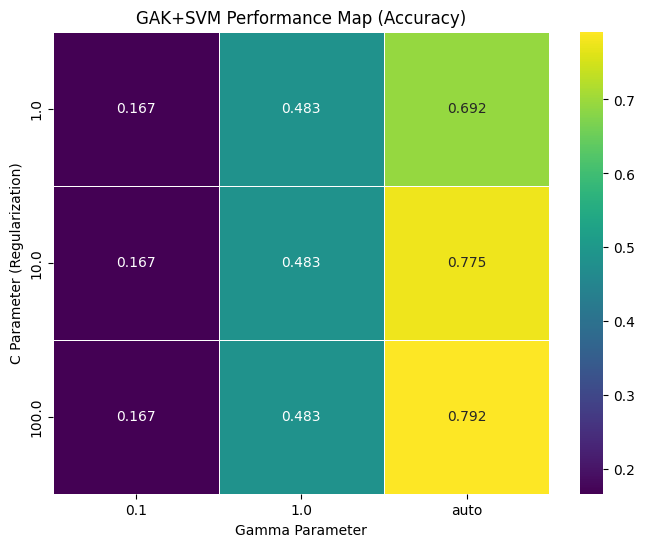


Best parameters:
C: 100.0
Gamma: auto
Accuracy: %79.17


In [23]:
import pandas as pd

# Visualization
df_results = pd.DataFrame(results)

# Pivot table (row: C, col: Gamma)
heatmap_data = df_results.pivot(index='C', columns='Gamma', values='Accuracy')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", linewidths=.5)
plt.title('GAK+SVM Performance Map (Accuracy)')
plt.ylabel('C Parameter (Regularization)')
plt.xlabel('Gamma Parameter')
plt.show()

best_run = df_results.loc[df_results['Accuracy'].idxmax()]
print("\nBest parameters:")
print(f"C: {best_run['C']}")
print(f"Gamma: {best_run['Gamma']}")
print(f"Accuracy: %{best_run['Accuracy']*100:.2f}")

Final GAK+SVM training is starting (C=100.0, Gamma=auto)


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    2.0s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    2.9s
[Parallel(n_jobs=1)]: Done 2449 tasks      | elapsed:    3.9s
[Parallel(n_jobs=1)]: Done 3199 tasks      | elapsed:    5.2s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    6.6s
[Parallel(n_jobs=1)]: Done 4999 tasks      | elapsed:    8.4s
[Parallel(n_jobs=1)]: Done 6049 tasks      | elapsed:   10.4s
[Parallel(n_jobs=1)]: Done 7199 tasks      | elapsed:   12.6s
[Parallel(n_jobs=1)]: Done 8449 tasks      | elapsed:   14.8s
[Parallel(n_jobs=1)]: Done 9799 tasks      | elapsed:   17.2s
[Parallel(n_jobs=1)]: Done 11249 tasks      | elapsed:   19.7s
[Parallel(n_jobs=1)]: Done 12799 tasks      | elapsed:   22.4s
[Parallel(

[LibSVM]

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    2.3s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    3.3s
[Parallel(n_jobs=1)]: Done 2449 tasks      | elapsed:    4.6s
[Parallel(n_jobs=1)]: Done 3199 tasks      | elapsed:    6.0s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    7.7s
[Parallel(n_jobs=1)]: Done 4999 tasks      | elapsed:    9.5s
[Parallel(n_jobs=1)]: Done 6049 tasks      | elapsed:   11.5s
[Parallel(n_jobs=1)]: Done 7199 tasks      | elapsed:   13.6s
[Parallel(n_jobs=1)]: Done 8449 tasks      | elapsed:   15.9s
[Parallel(n_jobs=1)]: Done 9799 tasks      | elapsed:   18.3s
[Parallel(n_jobs=1)]: Done 11249 tasks      | elapsed:   21.0s
[Parallel(n_jobs=1)]: Done 12799 tasks      | elapsed:   24.0s
[Parallel(


Final test accuracy: %79.17

GAK+SVM classification report
              precision    recall  f1-score   support

         Box       0.95      1.00      0.98        20
        Clap       0.79      0.95      0.86        20
        Wave       0.94      0.75      0.83        20
         Jog       0.57      0.60      0.59        20
         Run       0.72      0.65      0.68        20
        Walk       0.80      0.80      0.80        20

    accuracy                           0.79       120
   macro avg       0.80      0.79      0.79       120
weighted avg       0.80      0.79      0.79       120



[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.5s


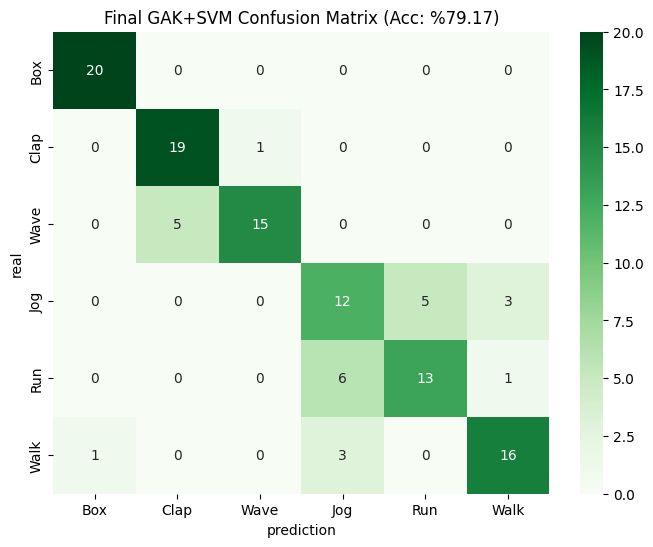

In [24]:
BEST_C = 100.0
BEST_GAMMA = "auto"

print(f"Final GAK+SVM training is starting (C={BEST_C}, Gamma={BEST_GAMMA})")
start_time = time.time()

clf = TimeSeriesSVC(kernel="gak", C=BEST_C, gamma=BEST_GAMMA, verbose=1)

clf.fit(X_train_g, y_train_g)

y_pred_final = clf.predict(X_test_g)
acc_final = accuracy_score(y_test_g, y_pred_final)

print(f"\nFinal test accuracy: %{acc_final * 100:.2f}")

# 4. Raporlama
print("\nGAK+SVM classification report")
print(classification_report(y_test_g, y_pred_final, target_names=['Box', 'Clap', 'Wave', 'Jog', 'Run', 'Walk']))

# 5. Confusion Matrix Çizimi
cm = confusion_matrix(y_test_g, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Box', 'Clap', 'Wave', 'Jog', 'Run', 'Walk'],
            yticklabels=['Box', 'Clap', 'Wave', 'Jog', 'Run', 'Walk'])
plt.title(f'Final GAK+SVM Confusion Matrix (Acc: %{acc_final*100:.2f})')
plt.ylabel('real')
plt.xlabel('prediction')
plt.show()

## --------------------------------------------------------------------------------------------------------------

# CNN

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" {device} is being used")

X_train_tensor = torch.tensor(np.nan_to_num(X_train_g, nan=0.0), dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_g, dtype=torch.long).to(device)

X_test_tensor = torch.tensor(np.nan_to_num(X_test_g, nan=0.0), dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_g, dtype=torch.long).to(device)

# create dataLoader (for batch training)
BATCH_SIZE = 16 
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"data is ready, input size: {X_train_tensor.shape}")

 cpu is being used
data is ready, input size: torch.Size([479, 364, 75])


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 35

train_losses = []
val_accuracies = []

print("CNN training is starting")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = 100 * correct / total
    train_losses.append(running_loss / len(train_loader))
    val_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {running_loss/len(train_loader):.4f}, Test Acc: %{val_acc:.2f}")

print("training completed")

CNN training is starting
Epoch [1/35], Loss: 1.3201, Test Acc: %56.67
Epoch [2/35], Loss: 0.9403, Test Acc: %56.67
Epoch [3/35], Loss: 0.8214, Test Acc: %70.00
Epoch [4/35], Loss: 0.7400, Test Acc: %65.83
Epoch [5/35], Loss: 0.6385, Test Acc: %72.50
Epoch [6/35], Loss: 0.6020, Test Acc: %64.17
Epoch [7/35], Loss: 0.5595, Test Acc: %72.50
Epoch [8/35], Loss: 0.5314, Test Acc: %80.00
Epoch [9/35], Loss: 0.4871, Test Acc: %69.17
Epoch [10/35], Loss: 0.4917, Test Acc: %77.50
Epoch [11/35], Loss: 0.4664, Test Acc: %70.83
Epoch [12/35], Loss: 0.4069, Test Acc: %65.00
Epoch [13/35], Loss: 0.3980, Test Acc: %72.50
Epoch [14/35], Loss: 0.3538, Test Acc: %80.83
Epoch [15/35], Loss: 0.3401, Test Acc: %81.67
Epoch [16/35], Loss: 0.3555, Test Acc: %65.00
Epoch [17/35], Loss: 0.3527, Test Acc: %77.50
Epoch [18/35], Loss: 0.3026, Test Acc: %77.50
Epoch [19/35], Loss: 0.3184, Test Acc: %78.33
Epoch [20/35], Loss: 0.3017, Test Acc: %79.17
Epoch [21/35], Loss: 0.2808, Test Acc: %75.00
Epoch [22/35], Los

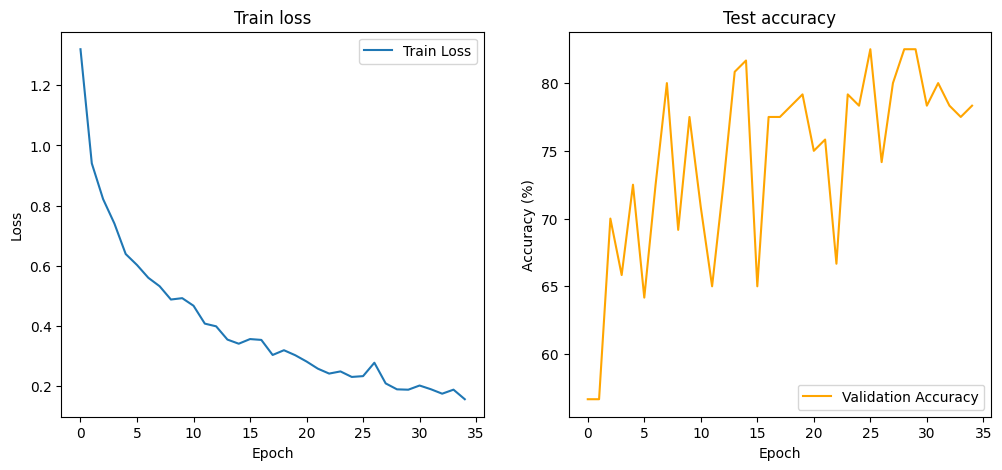


CNN classification report
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       1.00      0.95      0.97        20
           2       0.95      1.00      0.98        20
           3       0.56      0.25      0.34        20
           4       0.53      0.90      0.67        20
           5       0.74      0.70      0.72        20

    accuracy                           0.78       120
   macro avg       0.80      0.78      0.77       120
weighted avg       0.80      0.78      0.77       120



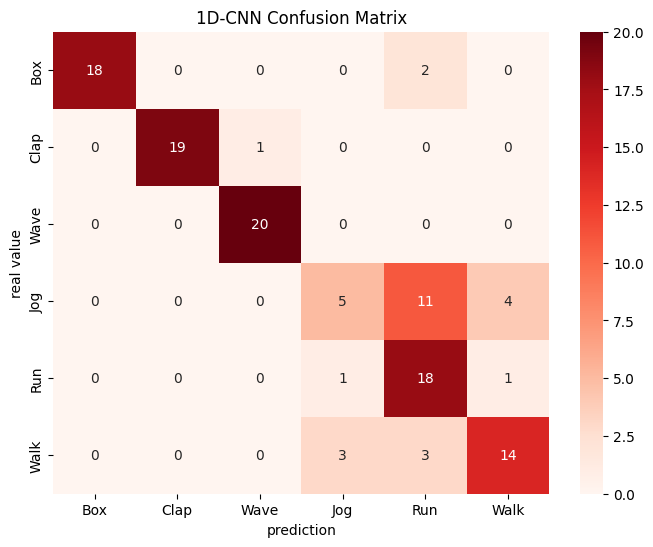

In [17]:
# Performance graph
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# Confusion Matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nCNN classification report")
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Box', 'Clap', 'Wave', 'Jog', 'Run', 'Walk'],
            yticklabels=['Box', 'Clap', 'Wave', 'Jog', 'Run', 'Walk'])
plt.title('1D-CNN Confusion Matrix')
plt.ylabel('real value')
plt.xlabel('prediction')
plt.show()


Experiment: LR=0.001, Batch=16, Dropout=0.5
Result: %78.33 Accuracy

Experiment: LR=0.01, Batch=16, Dropout=0.5
Result: %70.83 Accuracy

Experiment: LR=0.001, Batch=64, Dropout=0.5
Result: %81.67 Accuracy

Experiment: LR=0.001, Batch=16, Dropout=0.1
Result: %66.67 Accuracy


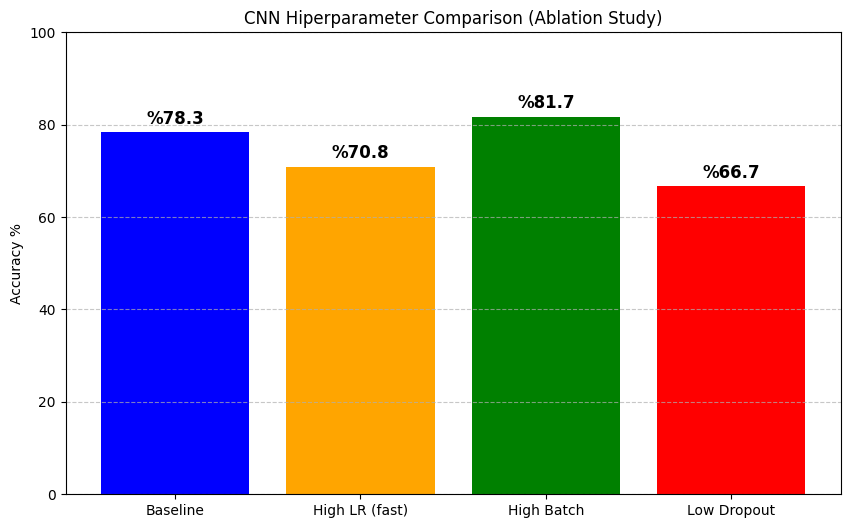


-Result Table
experiment name      | LR         | Batch      | Drop       | Accuracy  
----------------------------------------------------------------------
Baseline             | 0.001      | 16         | 0.5        | %78.33
High LR (fast)       | 0.01       | 16         | 0.5        | %70.83
High Batch           | 0.001      | 64         | 0.5        | %81.67
Low Dropout          | 0.001      | 16         | 0.1        | %66.67


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ActionCNN_Dynamic(nn.Module):
    def __init__(self, input_channels, num_classes, dropout_rate=0.5):
        super(ActionCNN_Dynamic, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)
        
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(dropout_rate) # Dinamik Dropout
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.permute(0, 2, 1) 
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

def run_experiment(lr, batch_size, dropout, epochs=20):
    print(f"\nExperiment: LR={lr}, Batch={batch_size}, Dropout={dropout}")
    
    train_ds = TensorDataset(X_train_tensor, y_train_tensor)
    test_ds = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    model = ActionCNN_Dynamic(input_channels=75, num_classes=6, dropout_rate=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # training cycle
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # Test accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    acc = 100 * correct / total
    print(f"Result: %{acc:.2f} Accuracy")
    return acc

experiments = [
    {'name': 'Baseline', 'lr': 0.001, 'batch': 16, 'dropout': 0.5},
    {'name': 'High LR (fast)', 'lr': 0.01,  'batch': 16, 'dropout': 0.5},
    {'name': 'High Batch',      'lr': 0.001, 'batch': 64, 'dropout': 0.5},
    {'name': 'Low Dropout',    'lr': 0.001, 'batch': 16, 'dropout': 0.1},
]

results = []
names = []

for exp in experiments:
    acc = run_experiment(exp['lr'], exp['batch'], exp['dropout'])
    results.append(acc)
    names.append(exp['name'])


plt.figure(figsize=(10, 6))
bars = plt.bar(names, results, color=['blue', 'orange', 'green', 'red'])

plt.ylabel('Accuracy %')
plt.title('CNN Hiperparameter Comparison (Ablation Study)')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'%{yval:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n-Result Table")
print(f"{'experiment name':<20} | {'LR':<10} | {'Batch':<10} | {'Drop':<10} | {'Accuracy':<10}")
print("-" * 70)
for i, exp in enumerate(experiments):
    print(f"{exp['name']:<20} | {exp['lr']:<10} | {exp['batch']:<10} | {exp['dropout']:<10} | %{results[i]:.2f}")

Final CNN model training is starting (LR=0.001, Batch=64)
Epoch 5/40 -> Loss: 0.7385 | Acc: %64.17
Epoch 10/40 -> Loss: 0.4501 | Acc: %81.67
Epoch 15/40 -> Loss: 0.3397 | Acc: %61.67
Epoch 20/40 -> Loss: 0.2812 | Acc: %79.17
Epoch 25/40 -> Loss: 0.2054 | Acc: %76.67
Epoch 30/40 -> Loss: 0.1997 | Acc: %78.33
Epoch 35/40 -> Loss: 0.1246 | Acc: %74.17
Epoch 40/40 -> Loss: 0.0754 | Acc: %79.17


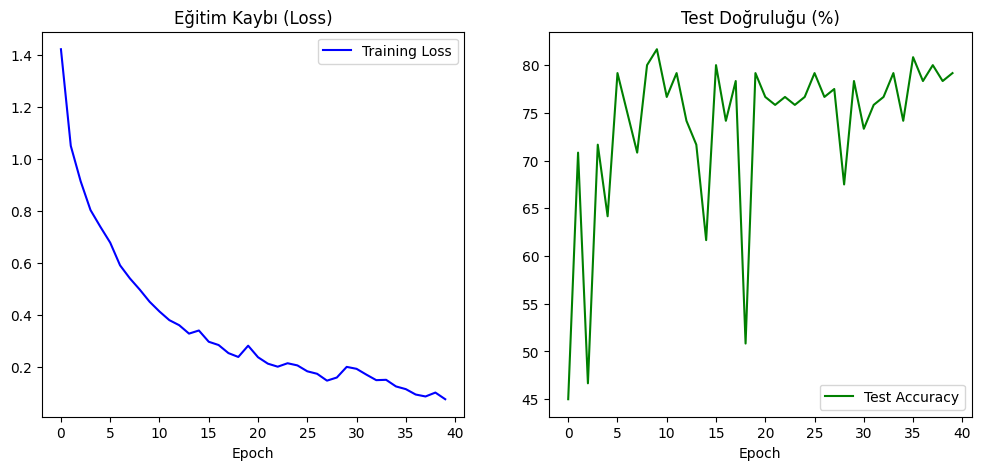


Final classifition report
              precision    recall  f1-score   support

         Box       1.00      0.95      0.97        20
        Clap       0.91      1.00      0.95        20
        Wave       0.95      0.95      0.95        20
         Jog       0.50      0.45      0.47        20
         Run       0.61      0.55      0.58        20
        Walk       0.74      0.85      0.79        20

    accuracy                           0.79       120
   macro avg       0.78      0.79      0.79       120
weighted avg       0.78      0.79      0.79       120



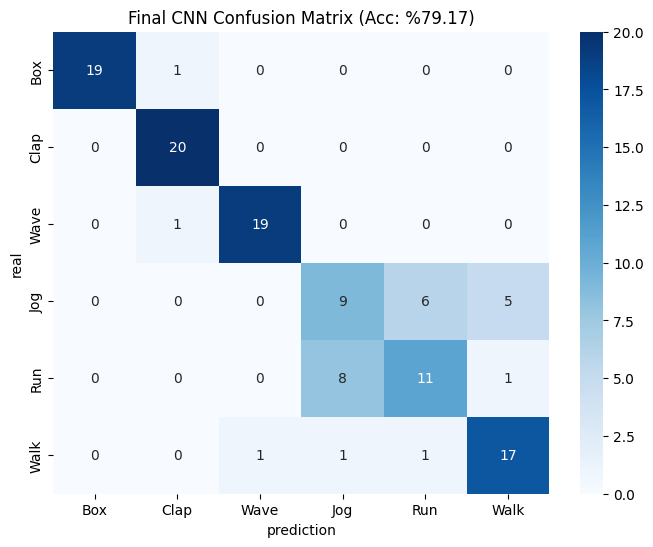

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

BEST_LR = 0.001      
BEST_BATCH = 64
BEST_DROPOUT = 0.5   
EPOCHS = 40          

# Cihaz
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=BEST_BATCH, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BEST_BATCH, shuffle=False)

model = ActionCNN_Dynamic(input_channels=75, num_classes=6, dropout_rate=BEST_DROPOUT).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)

train_losses = []
test_accuracies = []

print(f"Final CNN model training is starting (LR={BEST_LR}, Batch={BEST_BATCH})")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # Test Performance
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    train_losses.append(running_loss / len(train_loader))
    test_accuracies.append(acc)
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} -> Loss: {running_loss/len(train_loader):.4f} | Acc: %{acc:.2f}")


# Loss and Accuracy graphs
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.title('Eğitim Kaybı (Loss)')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy', color='green')
plt.title('Test Doğruluğu (%)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Confusion Matrix and report
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nFinal classifition report")
print(classification_report(all_labels, all_preds, target_names=['Box', 'Clap', 'Wave', 'Jog', 'Run', 'Walk']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Box', 'Clap', 'Wave', 'Jog', 'Run', 'Walk'],
            yticklabels=['Box', 'Clap', 'Wave', 'Jog', 'Run', 'Walk'])
plt.title(f'Final CNN Confusion Matrix (Acc: %{test_accuracies[-1]:.2f})')
plt.ylabel('real')
plt.xlabel('prediction')
plt.show()

# REPORT

## Global Alignment Kernel with Support Vector Machine

To measure the similarity between time series data, the Global Alignment Kernel (GAK), which is robust against temporal shifts, was used instead of the standard Euclidean distance. 

Data Structure: Since padding (adding zeros) negatively affects GAK performance, the variable-length data format of the tslearn library was used.
Downsampling: To reduce computational cost O(N^2), videos were downsampled by a factor of 5 (1 frame every 5 frames) and fed to the model. 
Scaling: Due to the sensitivity of SVM models to distance calculations, all data was normalized to the 0-1 range using TimeSeriesScalerMinMax. 

Hyperparameter Analysis (Ablation Study) 
A detailed Grid Search was performed on the Regularization (C) and Kernel Width (Gamma) parameters to optimize model performance. The results obtained are summarized in the following Heatmap and table: 
Critical Effect of the Gamma Parameter: When fixed values (gamma=0.1 and gamma=1.0) were used, the model's success remained at 16.67% (random prediction) and 48.33%, respectively. This indicates that fixed gamma values cannot cover the variance of high-dimensional skeleton data (75 features). 

When the gamma=‘auto’ option was used, a dramatic increase in accuracy rates was observed (in the range of 69% to 79%). The ‘auto’ mode yielded the most successful result because it performs dynamic scaling based on the median distance between time series in the dataset. 

Effect of the C Parameter: 
When Gamma is fixed to ‘auto’, performance improves as the C value increases.
While accuracy is 69.17% for C=1.0, the highest accuracy of 79.17% is achieved at C=100.0, where the model's tolerance to errors is reduced (approaching the hard margin).

Final Model Performance and Error Analysis
The overall accuracy of the final model trained with the best parameters (C=100.0, Gamma=‘auto’) was measured as 79.17% on the test set. Examining the Confusion Matrix yielded the following results:

Strong Classification:

Boxing: 20/20 (100%) success.
Handclapping: 19/20 success.

GAK is successful in capturing distinct patterns in upper body movements.

Misclassifications:

The greatest confusion occurred between the Jogging, Running, and Walking classes.
For example, 6 examples in the running class were misclassified as jogging, and 1 as walking. Similarly, the jogging class was also confused with running (5 examples).

Reason: The GAK algorithm focuses on the shape of the movement. Running and walking are kinematically very similar “cyclical” movements; the fundamental difference between them is speed. The downsampling process and the flexible structure of GAK may have dampened this speed difference to some extent.

Results
The GAK+SVM method demonstrated a performance comparable to deep learning models such as CNN (79.17%) when the correct gamma scaling (auto) was applied. The model delivered excellent results, particularly for clearly distinct movements such as waving, boxing, and clapping, but struggled with locomotor movements (walking/running), which are variations of each other.

## Suggesed Method - 1D Convolutional Neural Network

The 1D-CNN architecture was used as the proposed method for classifying skeleton data based on time series. Unlike recurrent networks such as LSTM, the CNN architecture aims to capture local patterns of motion (e.g., short-term features such as a hand raising) by using sliding windows (filters) along the time axis.

Input: Skeletal coordinate matrices of size (Batch Size, 75, Time_Steps).
Layers: Three Convolution blocks (Conv1d + BatchNorm + ReLU + MaxPool) were used.

Feature: To avoid being affected by different video lengths and to reduce the padding effect, a Global Average Pooling layer was added to reduce all time steps to a fixed feature vector.

Ablation Study
Comparative experiments were conducted on learning rate, batch size, and dropout rate to find the best configuration for the model.

Baseline: The (LR=0.001, Batch=16, Drop=0.5) configuration achieved 78.3% accuracy.

High LR (0.01): Increasing the learning rate caused the model to overshoot the optimum point, and the accuracy dropped to 70.8%.
Low Dropout (0.1): Lowering the dropout rate caused the model to overfit the training data and lose its generalization ability, resulting in the worst outcome (66.7%).
High Batch (64): Increasing the batch size made gradient calculations more stable and provided the highest accuracy at 81.7%.

As a result of this analysis, the final model trained for batch size = 64, lr=0.001.

Training Process:
During the 40 epoch training process conducted with the selected optimal parameters:

Loss: The training loss steadily decreased from 1.4 to 0.08 levels. This indicates that the model successfully learned the data.

Test Accuracy: Test accuracy could not follow a stabil trend, but the overall trend was upward and stabilized at around 80%.

Error Analysis (Confusion Matrix interpretation):
When examining the final model's performance on the test set (Accuracy: 79.17%), the following critical observations were made:

Excellence in Upper Body Movements:

Clapping: 20/20 (100%) success.
Boxing: 19/20 success.
Handwaving: 19/20 success.

The CNN model is successful in distinguishing distinct and characteristic hand movements.

Confusion in Lower Body and Similar Movements:

Jogging vs. Running: The model made the biggest mistake in these two classes. It correctly identified only 9 of the 20 examples in the jogging class, predicting 6 as running and 5 as walking.

From a kinematic perspective, “Jogging” and ‘Running’ are very similar actions. Differences in speed and stride length in the skeleton data made it difficult for the model to distinguish between these two classes. This is a common “Inter-class similarity” problem in computer vision.

Conclusion:
The 1D CNN method trained much faster and showed high performance, especially for hand and arm based movements. However, the error rate increased in cases where the entire body dynamics were very similar, such as running/walking.
